In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

In [3]:
pizza_df = pd.read_csv(r"E:\GUVI Projects\Dominos\Pizza_Sale.csv")
ingred_df = pd.read_csv(r"E:\GUVI Projects\Dominos\Pizza_Ingredients.csv")

In [4]:
pizza_df.dropna(inplace=True)

In [5]:
print("Missing values:\n", pizza_df.isna().sum())

Missing values:
 pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64


In [6]:
print("Duplicate rows:", pizza_df.duplicated().sum())

Duplicate rows: 0


In [7]:
date_formats = ['%d-%m-%Y', '%d/%m/%Y']
def parse_date(date_str):
    for fmt in date_formats:
        try:
            return pd.to_datetime(date_str, format=fmt)
        except ValueError:
            continue
    raise ValueError(f'No valid date format found for {date_str}')

pizza_df['order_date'] = pizza_df['order_date'].apply(parse_date)
pizza_df = pizza_df[['order_date', 'pizza_name', 'quantity']]

EDA

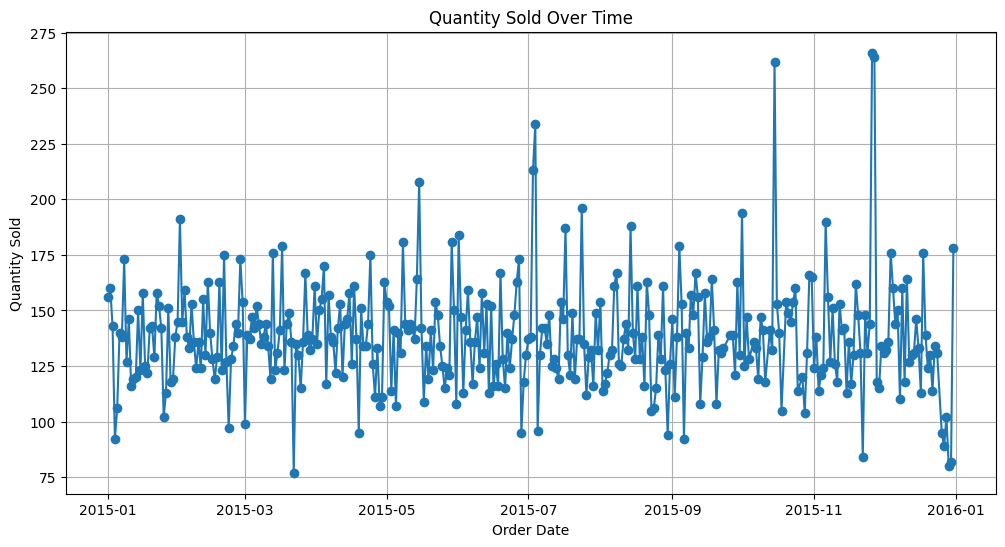

In [8]:
quantity_over_time = pizza_df.groupby('order_date')['quantity'].sum()
plt.figure(figsize=(12, 6))
plt.plot(quantity_over_time.index, quantity_over_time.values, marker='o')
plt.xlabel('Order Date')
plt.ylabel('Quantity Sold')
plt.title('Quantity Sold Over Time')
plt.grid(True)
plt.show()

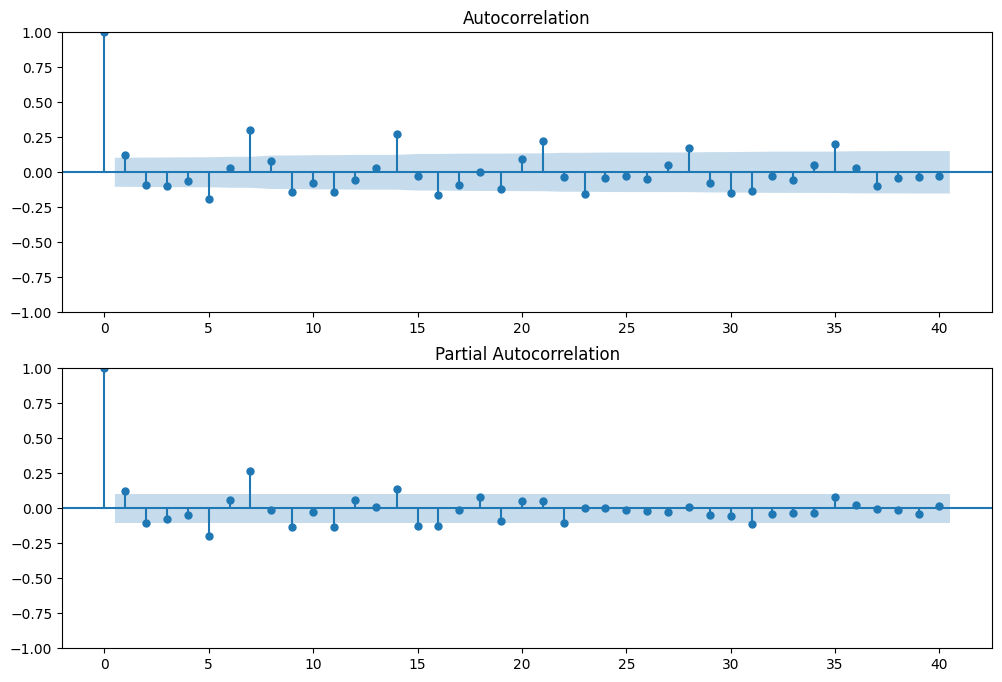

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(quantity_over_time, lags=40, ax=ax1)
plot_pacf(quantity_over_time, lags=40, ax=ax2)
plt.show()


In [10]:
result = adfuller(quantity_over_time)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
if result[1] <= 0.05:
    print('The series is stationary (reject H0)')
else:
    print('The series is not stationary (fail to reject H0)')


ADF Statistic: -5.2087
p-value: 0.0000
The series is stationary (reject H0)


In [11]:
eval_data = pizza_df.groupby(['order_date', 'pizza_name'])['quantity'].sum().unstack().fillna(0)
one_pizza = eval_data['The Barbecue Chicken Pizza']

In [12]:
train = one_pizza[:-7]
test = one_pizza[-7:]


ARIMA Model

In [13]:
arima_model = ARIMA(train, order=(1, 1, 0))
arima_result = arima_model.fit()

In [14]:
with open('arima_model_barbecue.pkl', 'wb') as file:
    pickle.dump(arima_result, file)

In [15]:
arima_forecast_obj = arima_result.get_forecast(steps=len(test))
arima_forecast = arima_forecast_obj.predicted_mean
arima_predict = arima_result.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=True)
arima_predict.index = test.index


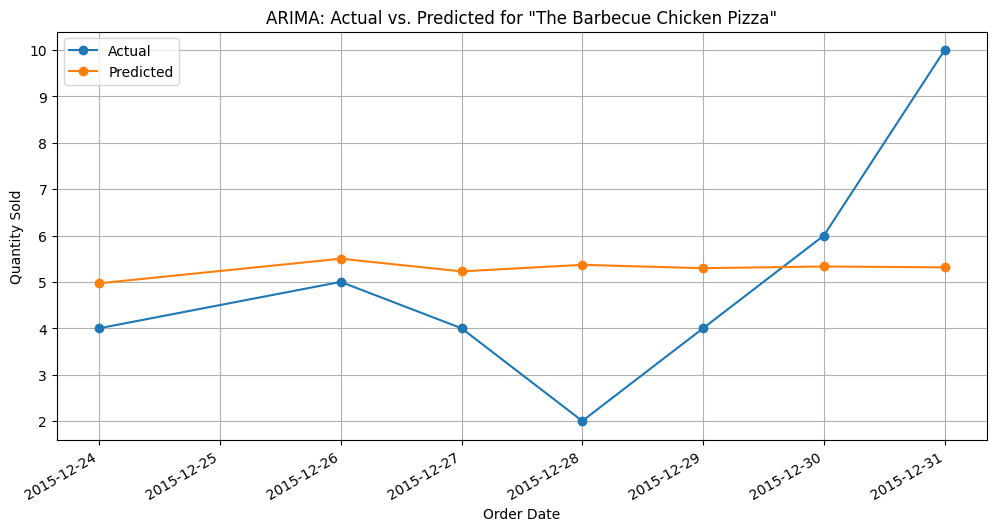

In [16]:
df_arima = pd.concat([test, arima_predict], axis=1)
df_arima.columns = ['Actual', 'Predicted']
df_arima.plot(figsize=(12, 6), marker='o')
plt.xlabel('Order Date')
plt.ylabel('Quantity Sold')
plt.title('ARIMA: Actual vs. Predicted for "The Barbecue Chicken Pizza"')
plt.grid(True)
plt.show()

In [17]:
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
print(f'ARIMA MAE: {arima_mae:.4f}, RMSE: {arima_rmse:.4f}')

ARIMA MAE: 1.8164, RMSE: 2.3338


SARIMA Model

In [18]:
sarima_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
sarima_result = sarima_model.fit()

In [20]:
with open('sarima_model_barbecue.pkl', 'wb') as file:
    pickle.dump(sarima_result, file)

In [21]:
sarima_forecast_obj = sarima_result.get_forecast(steps=len(test))
sarima_forecast = sarima_forecast_obj.predicted_mean

In [22]:
sarima_mae = mean_absolute_error(test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
print(f'SARIMA MAE: {sarima_mae:.4f}, RMSE: {sarima_rmse:.4f}')

SARIMA MAE: 2.5756, RMSE: 2.8803


In [23]:
sarima_predict = sarima_result.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=True)
sarima_predict.index = test.index

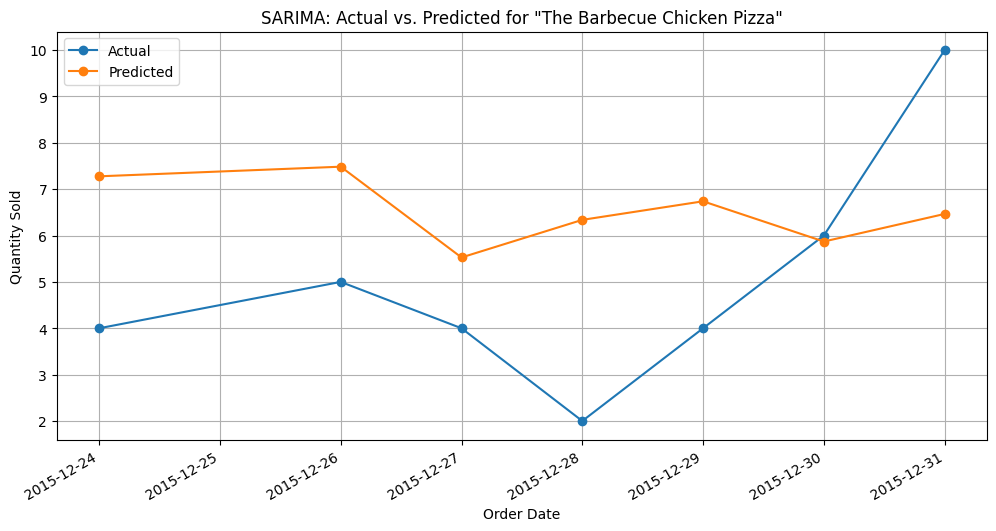

In [24]:
df_sarima = pd.concat([test, sarima_predict], axis=1)
df_sarima.columns = ['Actual', 'Predicted']
df_sarima.plot(figsize=(12, 6), marker='o')
plt.xlabel('Order Date')
plt.ylabel('Quantity Sold')
plt.title('SARIMA: Actual vs. Predicted for "The Barbecue Chicken Pizza"')
plt.grid(True)
plt.show()

Prophet Model

In [25]:
with open('prophet_model_barbecue.pkl', 'wb') as file:
    pickle.dump(pr_model, file)

NameError: name 'pr_model' is not defined

In [26]:
one_pizza_prophet = pd.DataFrame({'ds': one_pizza.index, 'y': one_pizza.values})
pr_train = one_pizza_prophet[:-7]
pr_test = one_pizza_prophet[-7:]

In [27]:
pr_model = Prophet()
pr_model.fit(pr_train)

20:09:13 - cmdstanpy - INFO - Chain [1] start processing
20:09:13 - cmdstanpy - INFO - Chain [1] done processing


In [28]:
with open('prophet_model_barbecue.pkl', 'wb') as file:
    pickle.dump(pr_model, file)

In [29]:
pr_future = pr_model.make_future_dataframe(periods=7, freq='D')
pr_forecast = pr_model.predict(pr_future)

In [30]:
pr_forecast_values = pr_forecast['yhat'][-7:].values
prophet_mae = mean_absolute_error(pr_test['y'], pr_forecast_values)
prophet_rmse = np.sqrt(mean_squared_error(pr_test['y'], pr_forecast_values))
print(f'Prophet MAE: {prophet_mae:.4f}, RMSE: {prophet_rmse:.4f}')

Prophet MAE: 2.7042, RMSE: 2.9256


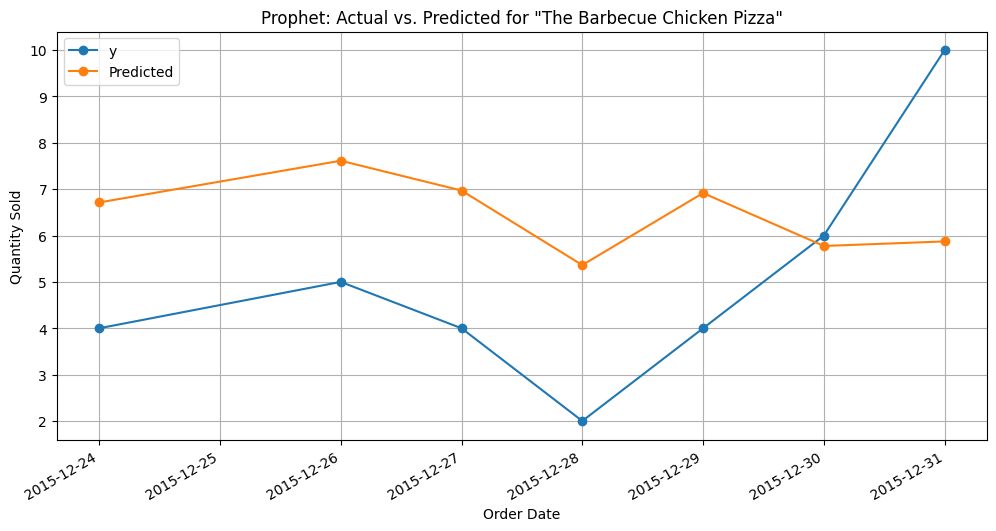

In [31]:
pr_test['Predicted'] = pr_forecast['yhat'][-7:].values
pr_test.set_index('ds', inplace=True)
pr_test.plot(figsize=(12, 6), marker='o')
plt.xlabel('Order Date')
plt.ylabel('Quantity Sold')
plt.title('Prophet: Actual vs. Predicted for "The Barbecue Chicken Pizza"')
plt.grid(True)
plt.show()